# Transcriptional Frontloading
with the new reference genome (nov 2025 release)

Following Barshis et al 2010, Gurr et al 2022, and Collins et al 2020

### general pipeline:
1. identify stress-inducible genes in control/naive oysters (uniquely DE in CS vs. CC, where S is a stressor)
    - separate up- and down-regulated DEGs
2. calculate mean vst expression for each treatment combo (CC, CS, SC, SS)
3. calculate baseline frontloading - "control ratio" - (SC / CC) with vst counts (y-axis)
4. calculate ratio of stress response - "response ratio" - ( (SS / SC) / CS / CC) ) with vst counts (x-axis)
5. plot!

## data prep:

### 1. load libraries

In [62]:
library(tidyverse)
library(cowplot)
library(VennDiagram)
library(RColorBrewer)

### 2. read CSVs

#### all genes

In [43]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# read each csv
file_list <- lapply(files, read.csv)

# name list elements after the files
names(file_list) <- tools::file_path_sans_ext(basename(files))

# check things worked
names(file_list)
head(file_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-0.0332488130,0.10018698,0.82750435,0.4079513,0.8964045,0.9922542,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-0.0078655573,0.14736612,0.62056406,0.5348865,0.9348872,0.9804099,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.0085061583,0.15147791,-0.68050588,0.4961842,0.9239532,0.9787085,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0001907784,0.32997597,-0.01429643,0.9885935,NA,0.9752358,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0026528705,0.33519956,0.19674097,0.8440303,NA,0.9699419,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0037226610,0.09670776,0.08951601,0.9286718,0.9959300,0.9930926,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


#### DEGs

In [44]:
deg_list <- lapply(file_list, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(deg_list)
head(deg_list$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111102506,948.578114,1.113463,1.3782539,-3.721539,1.980124e-04,4.376733e-02,2.293073e-01,822.0766309,290.844253,⋯,112.13493,230.21305,275.54002,1135.877800,179.4902221,280.52256,796.800632,234.39864,285.80926,204.172325
2,LOC111117765,948.580792,1.019382,0.7028216,-4.035920,5.438871e-05,1.923475e-02,1.031210e-01,1030.2093271,726.100756,⋯,1376.10241,948.80664,354.08763,785.360948,624.4763979,619.93344,1457.901593,607.65903,376.35189,546.966914
3,LOC111104782,61.439122,1.360622,1.1165575,-3.947402,7.900399e-05,2.436630e-02,8.045647e-02,73.1790758,105.027091,⋯,39.19279,32.06539,92.26227,8.127927,183.2296018,26.76742,59.151139,36.65950,33.81713,8.596729
4,LOC144619911,263.266792,-3.777067,3.9685711,3.967465,7.264103e-05,2.349671e-02,1.289212e-01,0.0000000,20.197518,⋯,0.00000,2431.21424,1034.83357,1.015991,0.9348449,0.00000,2.319652,5.55447,4.36350,0.000000
5,LOC111105268,370.537252,-1.988343,2.3808844,3.881096,1.039866e-04,2.795036e-02,1.789722e-01,0.9503776,1852.112359,⋯,17.41902,204.72518,351.59406,42.671617,365.5243586,94.22132,336.349612,1969.61509,644.70715,53.729559
6,LOC111102028,7.951088,21.008371,3.3828306,-6.378646,1.786602e-10,2.961740e-07,6.332811e-07,0.0000000,3.029628,⋯,59.87787,12.33284,0.00000,1.015991,0.0000000,0.00000,0.000000,0.00000,0.00000,4.298365


#### vst counts

In [45]:
vst <- file_list$bb_cc[,c(1,9:102)] %>%
column_to_rownames(var = 'Gene')
dim(vst)
head(vst)

[1] 29019    94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,2495.69160,2092.46282,2064.1625,1825.307015,1404.29352,1381.734279,1986.775,1493.836374,1645.83507,1679.237334,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
LOC144621269,52.27077,1648.11743,2375.9869,889.771163,2454.89589,1036.593201,6579.339,1502.147007,19.97642,7.026098,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
LOC111120925,66.52643,23.22715,448.6062,9.680992,17.45187,8.189788,0.000,1.038829,0.00000,1.003728,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
Trnae-cuc-2,0.00000,0.00000,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
Trnae-cuc-3,0.00000,0.00000,0.0000,0.000000,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
LOC144621283,540.76486,870.51301,891.4734,740.155834,819.07427,1091.581780,1054.960,455.007185,683.63749,762.833457,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


this is for individual samples, so will need to average across sample

### venn diagram 

Warning message in brewer.pal(2, "Set2"):
“minimal value for n is 3, returning requested palette with 3 different levels
”


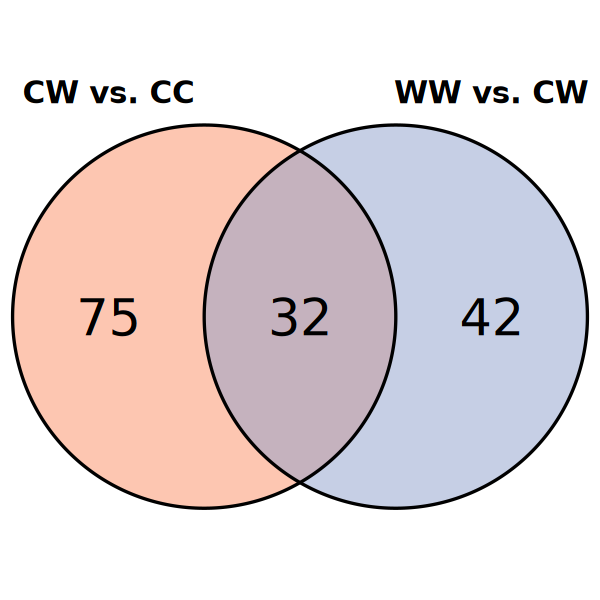

In [92]:
# Colors
myCol <- brewer.pal(2, "Set2")[2:3]

options(repr.plot.height = 5, repr.plot.width = 5)

# Create Venn diagram object
venn.plot <- venn.diagram(
    x = list(
        cw_cc = deg_list$cw_cc$Gene,
        ww_cw = deg_list$ww_cw$Gene
    ),
    
    category.names = c("CW vs. CC", "WW vs. CW"),
    
    filename = NULL,

    # Output features
    imagetype = "png",
    height = 480,
    width = 480,
    resolution = 300,
    compression = "lzw",

    # set circle size
    scaled = FALSE, 

    # Circles
    lwd = 2,
    fill = myCol,

    # Numbers
    cex = 2.5 ,
    # fontface = "bold",
    fontfamily = "sans",

    # Category labels
    cat.cex = 1.5,
    cat.fontface = "bold",
    cat.default.pos = "outer",
    cat.pos = c(-23, 23),
    cat.dist = c(0.055, 0.055),
    cat.fontfamily = "sans"
)

# Draw plot
grid.newpage()
grid.draw(venn.plot)

In [93]:
pdf("warm_fl_venn.pdf", width = 6, height = 6)

grid.newpage()
grid.draw(venn.plot)

dev.off()

png 
  2

## frontloading analysis

### 1. stress-inducible genes
genes uniquely DE in phase 1 control/naive oysters when phase 2 is either stress or naive conditions 

#### hypoxia
for hypoxia, these are DEGs in CH vs. CC (and not in HH vs. HC)

In [6]:
## HYPOXIA
hyp.uniq <- deg_list$ch_cc[!deg_list$ch_cc$Gene %in% deg_list$hh_hc$Gene, ]
dim(hyp.uniq) # 203 unique DEGs

# upregulated genes
hyp.uniq_UP <- hyp.uniq %>% filter(log2FoldChange > 0)
dim(hyp.uniq_UP) # 62 upregulated

# downregulated genes
hyp.uniq_DOWN <- hyp.uniq %>% filter(log2FoldChange < 0)
dim(hyp.uniq_DOWN) # 141 downregulated

[1] 121 102

[1]  43 102

[1]  78 102

In [7]:
head(hyp.uniq_DOWN)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111104083,358.57910,-1.175851,0.7202537,-4.371849,1.231988e-05,3.734381e-03,4.722926e-02,495.146734,318.110901,⋯,252.575758,272.96690,422.66094,263.141637,379.54703,397.2285,404.7794,247.729366,265.082635,412.64302
2,LOC144622046,14.76020,-13.725743,4.8870762,-4.454789,8.397588e-06,2.659865e-03,7.677456e-03,0.000000,0.000000,⋯,18.507706,0.00000,0.00000,5.079954,0.00000,0.0000,0.0000,0.000000,5.454375,0.00000
3,LOC144623974,81.47874,-21.038232,6.0739577,-4.633047,3.603227e-06,1.295698e-03,2.981394e-03,0.000000,0.000000,⋯,0.000000,0.00000,0.00000,67.055398,0.00000,1670.2870,0.0000,0.000000,0.000000,42.98365
4,LOC111104604,173.37211,-25.335749,4.4127972,-5.920273,3.214071e-09,1.969667e-06,3.902773e-06,0.000000,0.000000,⋯,0.000000,0.00000,0.00000,1192.773289,0.00000,0.0000,0.0000,0.000000,0.000000,191.27723
5,LOC111102592,140.21949,-2.878081,3.6689019,-3.777853,1.581864e-04,3.430211e-02,1.204309e-01,7.603021,1.009876,⋯,336.404782,26.31006,4.98715,12.191891,0.00000,0.0000,931.3405,2.221788,8.727000,751.13924
6,LOC111107583,28.58984,-1.409821,2.1268510,-3.749906,1.769007e-04,3.736918e-02,1.542318e-01,76.980586,12.118511,⋯,4.354754,35.35415,0.00000,4.063964,10.28329,0.0000,0.0000,3.332682,16.363126,27.93937


#### warm

In [46]:
## WARM
warm.uniq <- deg_list$cw_cc[!deg_list$cw_cc$Gene %in% deg_list$ww_wc$Gene, ]
dim(warm.uniq) # 107 unique DEGs

# upregulated genes
warm.uniq_UP <- warm.uniq %>% filter(log2FoldChange > 0)
dim(warm.uniq_UP) # 51 upregulated

# downregulated genes
warm.uniq_DOWN <- warm.uniq %>% filter(log2FoldChange < 0)
dim(warm.uniq_DOWN) # 56 downregulated

[1] 107 102

[1]  51 102

[1]  56 102

#### both

In [9]:
## BOTH
both.uniq <- deg_list$cb_cc[!deg_list$cb_cc$Gene %in% deg_list$bb_bc$Gene, ]
dim(both.uniq) # 145 unique DEGs

# upregulated genes
both.uniq_UP <- both.uniq %>% filter(log2FoldChange > 0)
dim(both.uniq_UP) # 62 upregulated

# downregulated genes
both.uniq_DOWN <- both.uniq %>% filter(log2FoldChange < 0)
dim(both.uniq_DOWN) # 83 downregulated

[1] 145 102

[1]  62 102

[1]  83 102

### 2. calculate mean vst expression for each treatment combo


In [10]:
metaData <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(All_treatment = factor(paste0(Phase1_treatment, '_', Phase2_treatment))) %>% # add column for p1 and p2 treatment combined, make treatment groups a factor
filter(!is.na(Phase2_treatment)) %>% # remove phase 1 samples
select(Sample, All_treatment) # grab only the needed columns 

dim(metaData)
head(metaData)

[1] 96  2

,Sample,All_treatment
,<chr>,<fct>
1,B1_B1_O01,both_both
2,B1_W5_O50,both_warm
3,B2_B5_O51,both_both
4,B2_C4_O40,both_control
5,B3_B4_O41,both_both
6,B3_C3_O30,both_control


In [11]:
# convert vsd to long format
vsd.df <- as.data.frame(vst)            # convert matrix to data frame
vsd.df$Gene <- rownames(vsd.df)            # keep gene names as a column

# Convert to long format
vsd_long <- vsd.df %>%
  pivot_longer(
    cols = -Gene,            # all columns except Gene
    names_to = "Sample",     # name of the column for sample names
    values_to = "Expression" # name of the column for values
  )

head(vsd_long)

Gene,Sample,Expression
<chr>,<chr>,<dbl>
LOC144621260,B1_B1_O01,2495.692
LOC144621260,B1_W5_O50,2092.463
LOC144621260,B2_B5_O51,2064.163
LOC144621260,B2_C4_O40,1825.307
LOC144621260,B3_B4_O41,1404.294
LOC144621260,B3_C3_O30,1381.734


In [12]:
meta_vsd <- merge(vsd_long, metaData, by = 'Sample')
head(meta_vsd)

,Sample,Gene,Expression,All_treatment
,<chr>,<chr>,<dbl>,<fct>
1,B1_B1_O01,LOC144621260,2495.691599,both_both
2,B1_B1_O01,LOC111128496,7.603021,both_both
3,B1_B1_O01,LOC144622275,0.000000,both_both
4,B1_B1_O01,LOC111128113,2513.748773,both_both
5,B1_B1_O01,LOC111109269,0.000000,both_both
6,B1_B1_O01,LOC111100618,92.186628,both_both


In [13]:
meanExpr.df <- meta_vsd %>%
group_by(Gene, All_treatment) %>%
select(-Sample) %>%
summarise(meanExp = mean(Expression)
)

vsd.mean.wide <- meanExpr.df %>%
  pivot_wider(
    names_from = All_treatment,   # column to spread out into multiple columns
    values_from = meanExp         # values to fill in the new columns
  )

head(vsd.mean.wide)

`summarise()` has grouped output by 'Gene'. You can override using the
`.groups` argument.


Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099029,137.1522391,123.907115,98.7353231,146.893344,128.767752,124.7239278,126.3853919,258.5287471,145.966555,118.4323842,99.2326122,151.896073,163.851169,134.146443,105.1218212,201.068823
LOC111099030,0.7107789,1.478764,0.4443095,3.863844,1.184112,0.9295190,0.0000000,13.9313480,41.240054,0.0000000,0.2139551,1.488374,1.145165,1.903238,1.4685337,11.326730
LOC111099032,1.2042508,0.422504,0.7996821,0.000000,2.578030,0.8594107,0.5984109,0.3386102,2.648469,0.6686996,0.0000000,7.247362,0.000000,0.000000,1.6030723,0.363625
LOC111099037,25.3673987,1.267512,1.0661177,1.638723,20.778178,0.7790172,0.4685708,26.1910682,0.000000,8.4953130,0.0000000,0.000000,25.380740,23.656299,0.3386636,2.542612
LOC111099039,20.7176208,40.030007,28.9670482,14.768286,39.226311,26.3362177,21.9259117,14.6050801,24.821929,20.8835347,19.6235463,17.557328,22.233808,22.261515,24.6798518,15.443548
LOC111099040,3447.2926290,3611.105839,4002.3122949,3230.304512,3258.216882,3158.3327196,3577.0310883,2914.9694245,3190.146519,2880.2049899,2966.4940699,3315.889422,3036.482969,2922.165172,3175.7918502,3045.210973


### 3. calculate baseline frontloading
"control ratio"

#### hypoxia
(HC / CC) with vst counts (y-axis)

In [14]:
# HYPOXIA
# pull out genes of interest

## UP
hyp.vsd_UP <- vsd.mean.wide[vsd.mean.wide$Gene %in% hyp.uniq_UP$Gene,]
dim(hyp.vsd_UP)

## DOWN
hyp.vsd_DOWN <- vsd.mean.wide[vsd.mean.wide$Gene %in% hyp.uniq_DOWN$Gene,]
head(hyp.vsd_DOWN)
dim(hyp.vsd_DOWN)

[1] 43 17

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111100601,0.000000,1.317053,1.657102,1.744547,29.992849,1.768917,0.000000,0.6873284,0.3902261,7.653552,0.7803143,1.263948,0.2975617,0.2276060,0.1947965,0.00000
LOC111101702,7.463178,5.586212,58.427353,45.568228,9.965352,36.620212,0.000000,35.2846529,0.0000000,14.964407,49.7450367,1.259090,18.0108942,0.8311916,35.9960594,33.60544
LOC111102592,36.873912,15.967928,2.228555,29.343570,30.831263,873.580087,5.627702,363.2444714,215.3284862,24.007917,13.5760753,135.018670,167.0331696,81.1525388,23.4362667,184.44544
LOC111104083,390.959432,519.012560,237.395443,346.878204,267.690040,825.032313,250.867430,369.4742315,208.6952008,401.137427,257.8115402,284.864747,299.8471507,345.1449506,385.2712218,357.12809
LOC111104484,280.666564,251.564913,138.141439,192.064006,164.657982,419.019005,92.555285,311.3639036,215.2530642,124.230387,120.9031949,178.107836,220.7635616,216.0353846,138.4312193,326.83644
LOC111104604,28.057817,0.000000,323.302981,383.774013,121.766685,532.708535,0.000000,110.3126789,36.1240172,247.360787,131.5807214,221.576547,0.0000000,163.7878623,302.4228721,135.31761


[1] 78 17

In [15]:
## UP
hypUP.y <- (hyp.vsd_UP$hypoxic_control / hyp.vsd_UP$control_control)

## DOWN
hypDOWN.y <- (hyp.vsd_DOWN$hypoxic_control / hyp.vsd_DOWN$control_control)

#### warm

(WC / CC) for y-axis

In [16]:
# WARMING
# pull out genes of interest

## UP
warm.vsd_UP <- vsd.mean.wide[vsd.mean.wide$Gene %in% warm.uniq_UP$Gene,]
dim(warm.vsd_UP)

## DOWN
warm.vsd_DOWN <- vsd.mean.wide[vsd.mean.wide$Gene %in% warm.uniq_DOWN$Gene,]
head(warm.vsd_DOWN)
dim(warm.vsd_DOWN)

[1] 51 17

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099527,5.694204,0.000000,0.000000,0.000000,0.3613596,6.134826,10.304822,0.000000,6.057981,1.0627957,0.000000,0.3411345,39.426920,15.118149,0.555447,3.223774
LOC111099940,50.700985,3.588753,2.630758,1.703369,59.5742250,83.507662,77.168152,1.419218,2.761812,0.6663823,1.442870,3.3455309,2.407328,1.219742,81.572968,3.160736
LOC111099953,16.942902,1.319671,20.052997,6.025893,6.1391788,230.627872,5.285433,3.089257,10.331899,8.1072886,8.035151,9.0324269,7.155150,6.842602,32.601386,2.722103
LOC111101301,11.124467,334.480071,420.588562,552.884699,3088.8526265,5176.614388,2461.252470,26.122148,7.572395,9.9526771,25.388584,487.3048041,662.996865,1996.730896,893.850763,12.248468
LOC111102978,114.642854,151.255436,176.153564,250.096914,277.4193923,483.534359,36.869633,12.284151,479.170093,93.4435792,341.260492,80.9355504,122.326495,44.845750,151.007362,48.951038
LOC111103928,66.722450,75.739984,24.997764,6.048910,20.3706997,189.435542,70.501227,0.000000,10.120424,176.4015519,142.335468,3.7009895,162.635568,52.862851,161.457067,96.268700


[1] 56 17

In [17]:
## WARMING
## UP
warmUP.y <- (warm.vsd_UP$warm_control / warm.vsd_UP$control_control)

## DOWN
warmDOWN.y <- (warm.vsd_DOWN$warm_control / warm.vsd_DOWN$control_control)

#### both
(BC / CC) for y-axis

In [18]:
# BOTH
# pull out genes of interest

## UP
both.vsd_UP <- vsd.mean.wide[vsd.mean.wide$Gene %in% both.uniq_UP$Gene,]
dim(both.vsd_UP)

## DOWN
both.vsd_DOWN <- vsd.mean.wide[vsd.mean.wide$Gene %in% both.uniq_DOWN$Gene,]
head(both.vsd_DOWN)
dim(both.vsd_DOWN)

[1] 62 17

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099732,173.9810340,11.5135955,12.4330338,8.023998,11.62889,274.9140998,440.049637,50.2915733,372.598203,44.888296,19.621524,36.9978420,1102.360462,630.6061441,20.5317287,65.929936
LOC111100157,72.4914289,0.0000000,5.6185428,0.000000,0.00000,84.3433753,1.196822,8.0432503,3.654122,98.126240,0.000000,3.3575730,21.486863,26.4160191,0.0000000,0.000000
LOC111101052,19.9122973,0.7040721,0.8908264,1.674930,0.00000,9.3343535,65.002507,3.6427035,33.686647,5.213285,6.854064,1.3961252,62.182512,60.0943533,3.8742552,8.492529
LOC111101393,2.1861021,5.8222111,2.9066385,3.370947,0.00000,24.9127028,1.300869,4.3201182,3.913717,3.148300,1.000071,0.9067893,5.355315,12.0015032,13.5943462,6.126036
LOC111101566,0.8914731,0.7405028,0.0000000,1.659607,0.00000,0.1558005,0.248801,0.7008506,23.917971,1.955228,1.714407,0.6927981,19.049963,0.9866137,0.8436777,9.767160
LOC111101994,0.9565165,2.2355227,0.3599425,22.960138,0.00000,12.2116757,4.841898,47.4613903,5.965158,9.094216,17.870256,28.3211185,9.592245,56.3338917,5.9471472,1.869690


[1] 83 17

In [19]:
## BOTH
## UP
bothUP.y <- (both.vsd_UP$both_control / both.vsd_UP$control_control)

## DOWN
bothDOWN.y <- (both.vsd_DOWN$both_control / both.vsd_DOWN$control_control)

### 4. calculate ratio of stress response
"response ratio"

( (HH / HC) / CH / CC) ) with vst counts (x-axis)

In [20]:
## UP
hypUP.x <- ( (hyp.vsd_UP$hypoxic_hypoxic / hyp.vsd_UP$hypoxic_control ) / (hyp.vsd_UP$control_hypoxic / hyp.vsd_UP$control_control) )

## DOWN
hypDOWN.x <- ( (hyp.vsd_DOWN$hypoxic_hypoxic / hyp.vsd_DOWN$hypoxic_control ) / (hyp.vsd_DOWN$control_hypoxic / hyp.vsd_DOWN$control_control) )

In [21]:
## UP
hyp.vsd_UP$x.axis <- hypUP.x
hyp.vsd_UP$y.axis <- hypUP.y
head(hyp.vsd_UP)

## DOWN
hyp.vsd_DOWN$x.axis <- hypDOWN.x
hyp.vsd_DOWN$y.axis <- hypDOWN.y

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm,x.axis,y.axis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099855,2.272589,6.5712333,1.3384145,11.4540798,2.391788,3.571204,85.19889,46.030674,2.8316598,5.711137,3.025406,6.553255,3.337818,1.482255,3.5006485,6.268607,0.02220454,1.599219
LOC111099988,0.000000,67.8118848,0.0000000,0.0000000,138.380028,0.000000,19.03982,37.404431,40.8755797,0.000000,13.907084,16.206743,16.168963,0.000000,0.0000000,202.677530,NaN,NaN
LOC111100026,12.854058,6.0904169,0.5330588,60.9119633,6.541143,0.000000,14.93632,12.359273,18.5418919,29.805018,2.182128,7.624967,29.309830,0.000000,2.4069370,37.280506,0.00000000,Inf
LOC111102028,9.765492,0.7902319,20.9669808,0.5049379,8.180054,0.000000,14.83737,3.685393,13.3986353,0.977353,0.909220,15.351054,18.123624,4.183101,0.1693318,13.007505,0.00000000,Inf
LOC111102552,0.000000,7.1916342,0.0000000,19.0281480,0.000000,0.000000,20.30473,0.000000,0.1722332,0.000000,2.340943,63.280455,20.085181,17.430637,47.3192548,7.636125,NaN,NaN
LOC111106189,485.147934,230.9325750,427.4457074,174.2814812,443.242923,171.174397,495.06482,206.154818,341.5857832,222.252237,442.723187,192.029660,414.108283,236.454185,406.7710123,213.103796,0.68875199,1.298396


( (WW / WC) / CW / CC) ) with vst counts (x-axis)

In [22]:
## WARM
## UP
warmUP.x <- ( (warm.vsd_UP$warm_warm / warm.vsd_UP$warm_control ) / (warm.vsd_UP$control_warm / warm.vsd_UP$control_control) )

## DOWN
warmDOWN.x <- ( (warm.vsd_DOWN$warm_warm / warm.vsd_DOWN$warm_control ) / (warm.vsd_DOWN$control_warm / warm.vsd_DOWN$control_control) )

In [23]:
## WARM
## UP
warm.vsd_UP$x.axis <- warmUP.x
warm.vsd_UP$y.axis <- warmUP.y
head(warm.vsd_UP)

## DOWN
warm.vsd_DOWN$x.axis <- warmDOWN.x
warm.vsd_DOWN$y.axis <- warmDOWN.y

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm,x.axis,y.axis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099077,6.436961,3.3800316,0.4443095,1.6230355,4.528351,0.000000,0.000000,43.245286,1.097388,1.417061,0.000000,10.311334,13.903254,5.542995,0.1947965,17.467269,0.0000000,Inf
LOC111099988,0.000000,67.8118848,0.0000000,0.0000000,138.380028,0.000000,19.039819,37.404431,40.875580,0.000000,13.907084,16.206743,16.168963,0.000000,0.0000000,202.677530,NaN,NaN
LOC111100026,12.854058,6.0904169,0.5330588,60.9119633,6.541143,0.000000,14.936316,12.359273,18.541892,29.805018,2.182128,7.624967,29.309830,0.000000,2.4069370,37.280506,NaN,NaN
LOC111102028,9.765492,0.7902319,20.9669808,0.5049379,8.180054,0.000000,14.837374,3.685393,13.398635,0.977353,0.909220,15.351054,18.123624,4.183101,0.1693318,13.007505,0.0000000,Inf
LOC111103088,10.324486,9.7661749,6.4945595,8.7274670,8.224623,8.047298,11.010672,82.522610,9.729714,5.947547,24.671717,11.629239,12.028183,3.769622,9.1561360,9.621814,0.2489065,0.4684333
LOC111105472,22.588399,17.3856832,305.4999525,249.8199239,102.783612,4.449068,3.791046,372.663605,66.526705,120.249629,308.627017,34.322745,5.853987,10.527746,18.3470166,429.840790,0.4874435,2.3662810


( (BB / BC) / CB / CC) ) with vst counts (x-axis)

In [24]:
## BOTH
## UP
bothUP.x <- ( (both.vsd_UP$both_both / both.vsd_UP$both_control ) / (both.vsd_UP$control_both / both.vsd_UP$control_control) )

## DOWN
bothDOWN.x <- ( (both.vsd_DOWN$both_both / both.vsd_DOWN$both_control ) / (both.vsd_DOWN$control_both / both.vsd_DOWN$control_control) )

In [25]:
## BOTH
## UP
both.vsd_UP$x.axis <- bothUP.x
both.vsd_UP$y.axis <- bothUP.y
head(both.vsd_UP)

## DOWN
both.vsd_DOWN$x.axis <- bothDOWN.x
both.vsd_DOWN$y.axis <- bothDOWN.y

Gene,both_both,both_control,both_hypoxic,both_warm,control_both,control_control,control_hypoxic,control_warm,hypoxic_both,hypoxic_control,hypoxic_hypoxic,hypoxic_warm,warm_both,warm_control,warm_hypoxic,warm_warm,x.axis,y.axis
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111099077,6.436961,3.3800316,0.4443095,1.6230355,4.528351,0.00000,0.00000,43.245286,1.097388,1.417061,0.000000,10.311334,13.90325,5.542995,0.1947965,17.46727,0.00000000,Inf
LOC111099988,0.000000,67.8118848,0.0000000,0.0000000,138.380028,0.00000,19.03982,37.404431,40.875580,0.000000,13.907084,16.206743,16.16896,0.000000,0.0000000,202.67753,0.00000000,Inf
LOC111100026,12.854058,6.0904169,0.5330588,60.9119633,6.541143,0.00000,14.93632,12.359273,18.541892,29.805018,2.182128,7.624967,29.30983,0.000000,2.4069370,37.28051,0.00000000,Inf
LOC111100718,37.435813,28.8662964,25.0874639,42.9255149,265.156165,25.19768,37.31777,46.911731,149.124419,47.535693,343.216582,20.779504,26.90174,35.978663,105.1253999,43.94884,0.12324097,1.145593
LOC111100784,38.583159,27.9960117,20.6568996,25.2819060,219.888136,14.09333,23.27352,25.930624,124.540104,20.337100,16.471070,111.265472,23.96239,13.730070,16.4031649,30.81395,0.08833107,1.986472
LOC111102028,9.765492,0.7902319,20.9669808,0.5049379,8.180054,0.00000,14.83737,3.685393,13.398635,0.977353,0.909220,15.351054,18.12362,4.183101,0.1693318,13.00751,0.00000000,Inf


### 5. plot!

#### HYPOXIA

In [33]:
hyp.UP.plot <- ggplot(hyp.vsd_UP, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_smooth(method = "loess") +
geom_hline(yintercept = 1, color = 'grey') + 
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'hypoxia response ratio: ( (HH / HC) / (CH / CC) )',
     y = 'hypoxia control ratio: (HC / CC)',
    title = 'upregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

In [27]:
hyp.DOWN.plot <- ggplot(hyp.vsd_DOWN, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_smooth(method = 'loess') +
geom_hline(yintercept = 1, color = 'grey') + 
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'hypoxia response ratio: ( (HH / HC) / (CH / CC) )',
     y = 'hypoxia control ratio: (HC / CC)',
    title = 'downregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 28 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 54 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_point()`).”


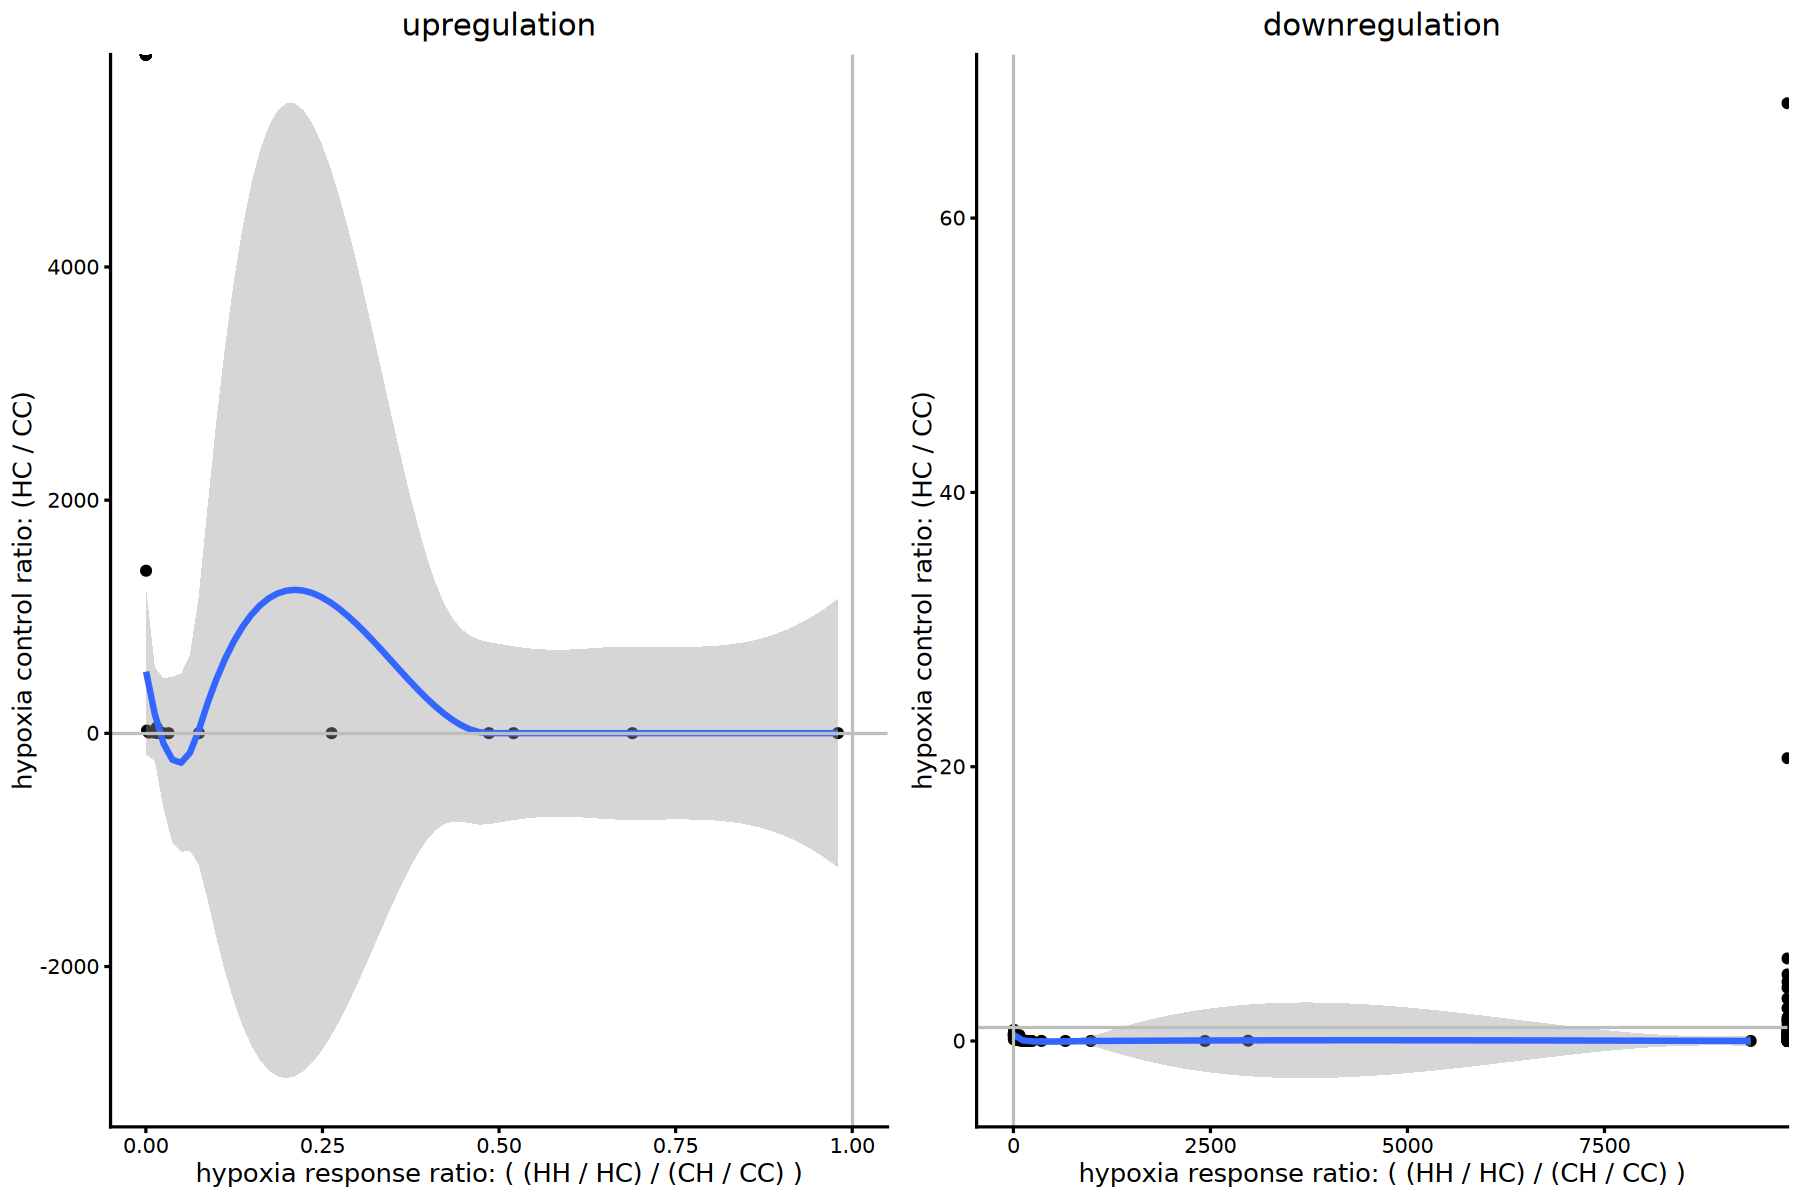

In [34]:
options(repr.plot.width=15, repr.plot.height=10)

plot_grid(hyp.UP.plot, hyp.DOWN.plot)

i'm actually not sure if i did the down-regulated genes correctly

also after using the new reference genome, this looks completely different .... i need to double check the math

although, it definitely has to do with the ratio number - the x axis is in the 1000s

#### WARM

In [35]:
warm.UP.plot <- ggplot(warm.vsd_UP, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_hline(yintercept = 1, color = 'grey') + 
geom_smooth(method = 'loess') +
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'warm response ratio: ( (WW / WC) / (CW / CC) )',
     y = 'warm control ratio: (WC / CC)',
    title = 'upregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

In [36]:
warm.DOWN.plot <- ggplot(warm.vsd_DOWN, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_hline(yintercept = 1, color = 'grey') + 
geom_smooth(method = 'loess') +
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'warm response ratio: ( (WW / WC) / (CW / CC) )',
     y = 'warm control ratio: (WC / CC)',
    title = 'downregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 32 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 34 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


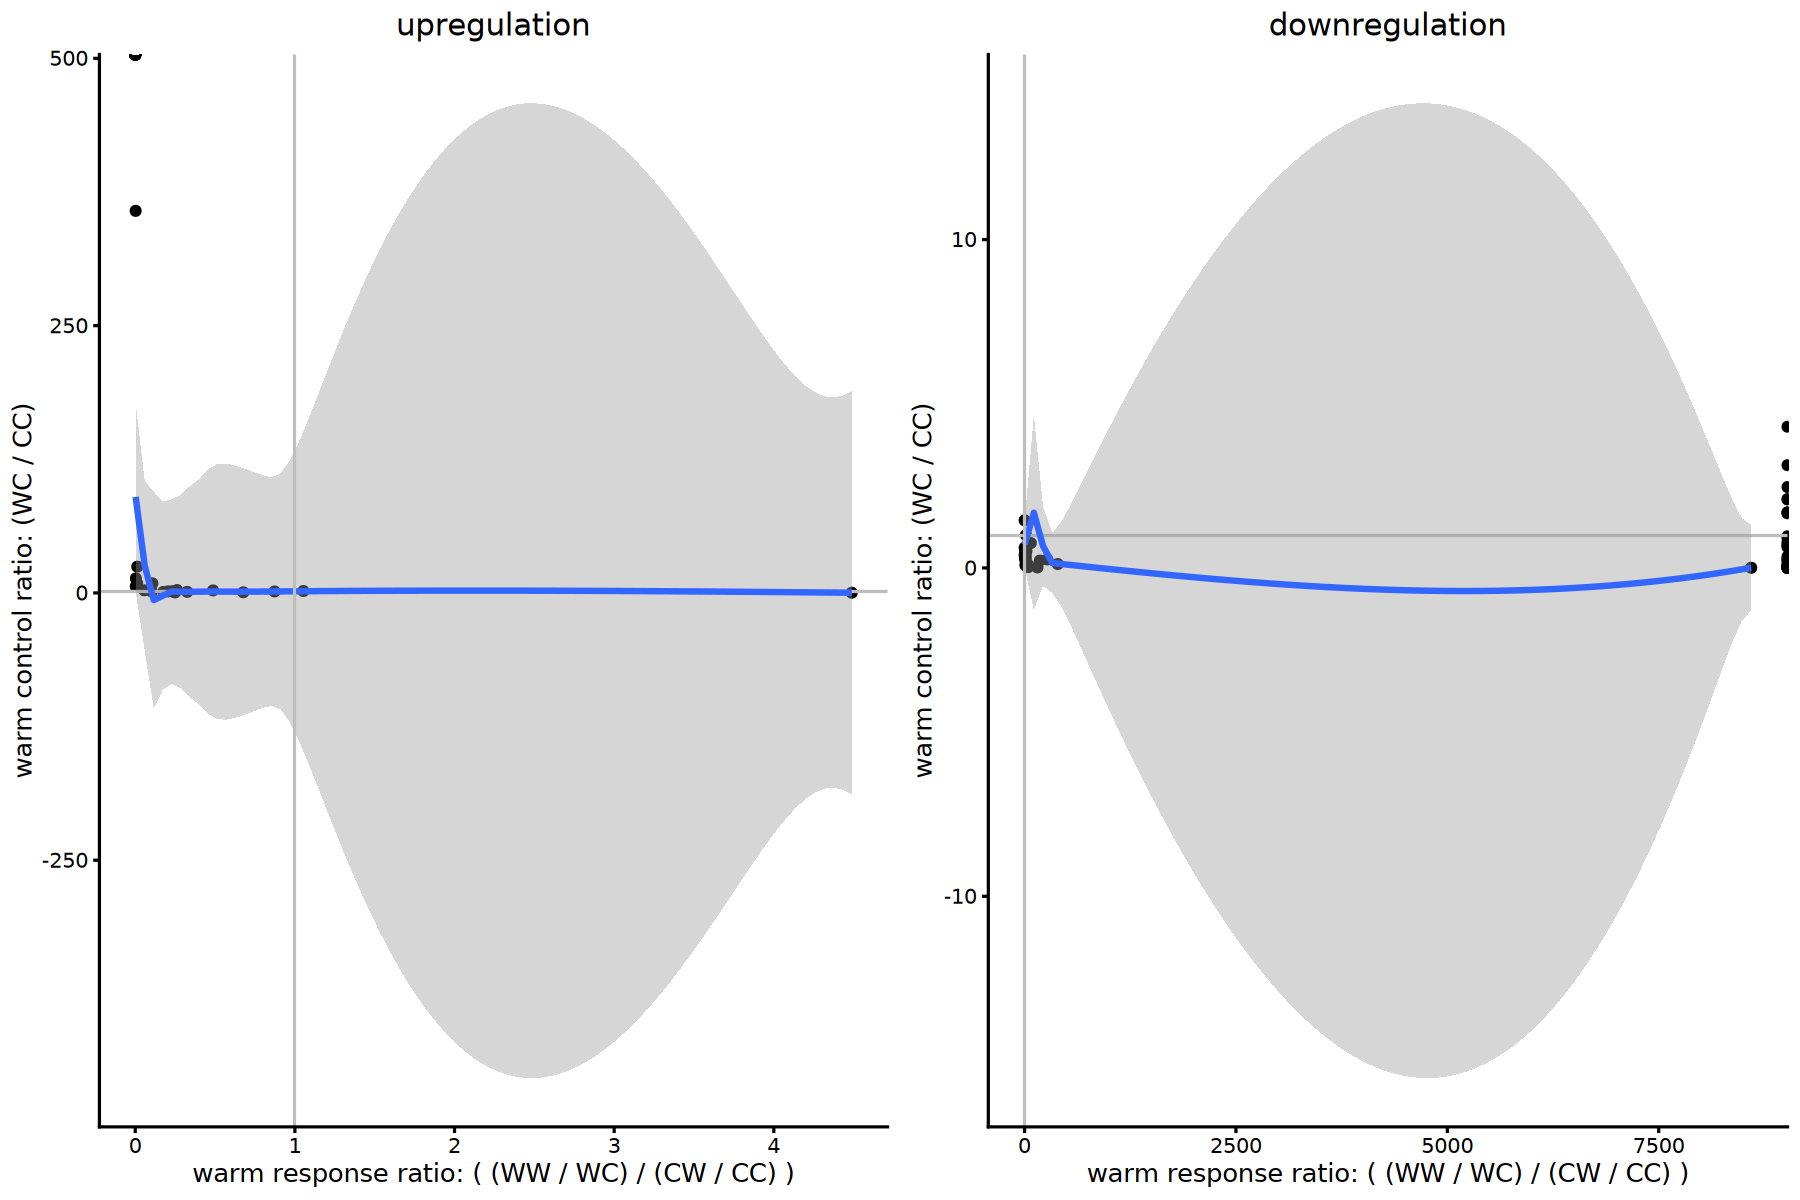

In [37]:
options(repr.plot.width=15, repr.plot.height=10)

plot_grid(warm.UP.plot, warm.DOWN.plot)

okay yea these axes are huge

#### BOTH

In [38]:
both.UP.plot <- ggplot(both.vsd_UP, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_smooth(method = 'loess') +
geom_hline(yintercept = 1, color = 'grey') + 
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'both response ratio: ( (BB / BC) / (CB / CC) )',
     y = 'both control ratio: (BC / CC)',
    title = 'upregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

In [39]:
both.DOWN.plot <- ggplot(both.vsd_DOWN, aes(x = x.axis, y = y.axis)) +
geom_point() + 
geom_smooth(method = 'loess') +
geom_hline(yintercept = 1, color = 'grey') + 
geom_vline(xintercept = 1, color = 'grey') +
labs(x = 'both response ratio: ( (BB / BC) / (CB / CC) )',
     y = 'both control ratio: (BC / CC)',
    title = 'downregulation') + 
theme_classic(base_size = 15) +
theme(plot.title = element_text(hjust = .5)) 

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 34 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


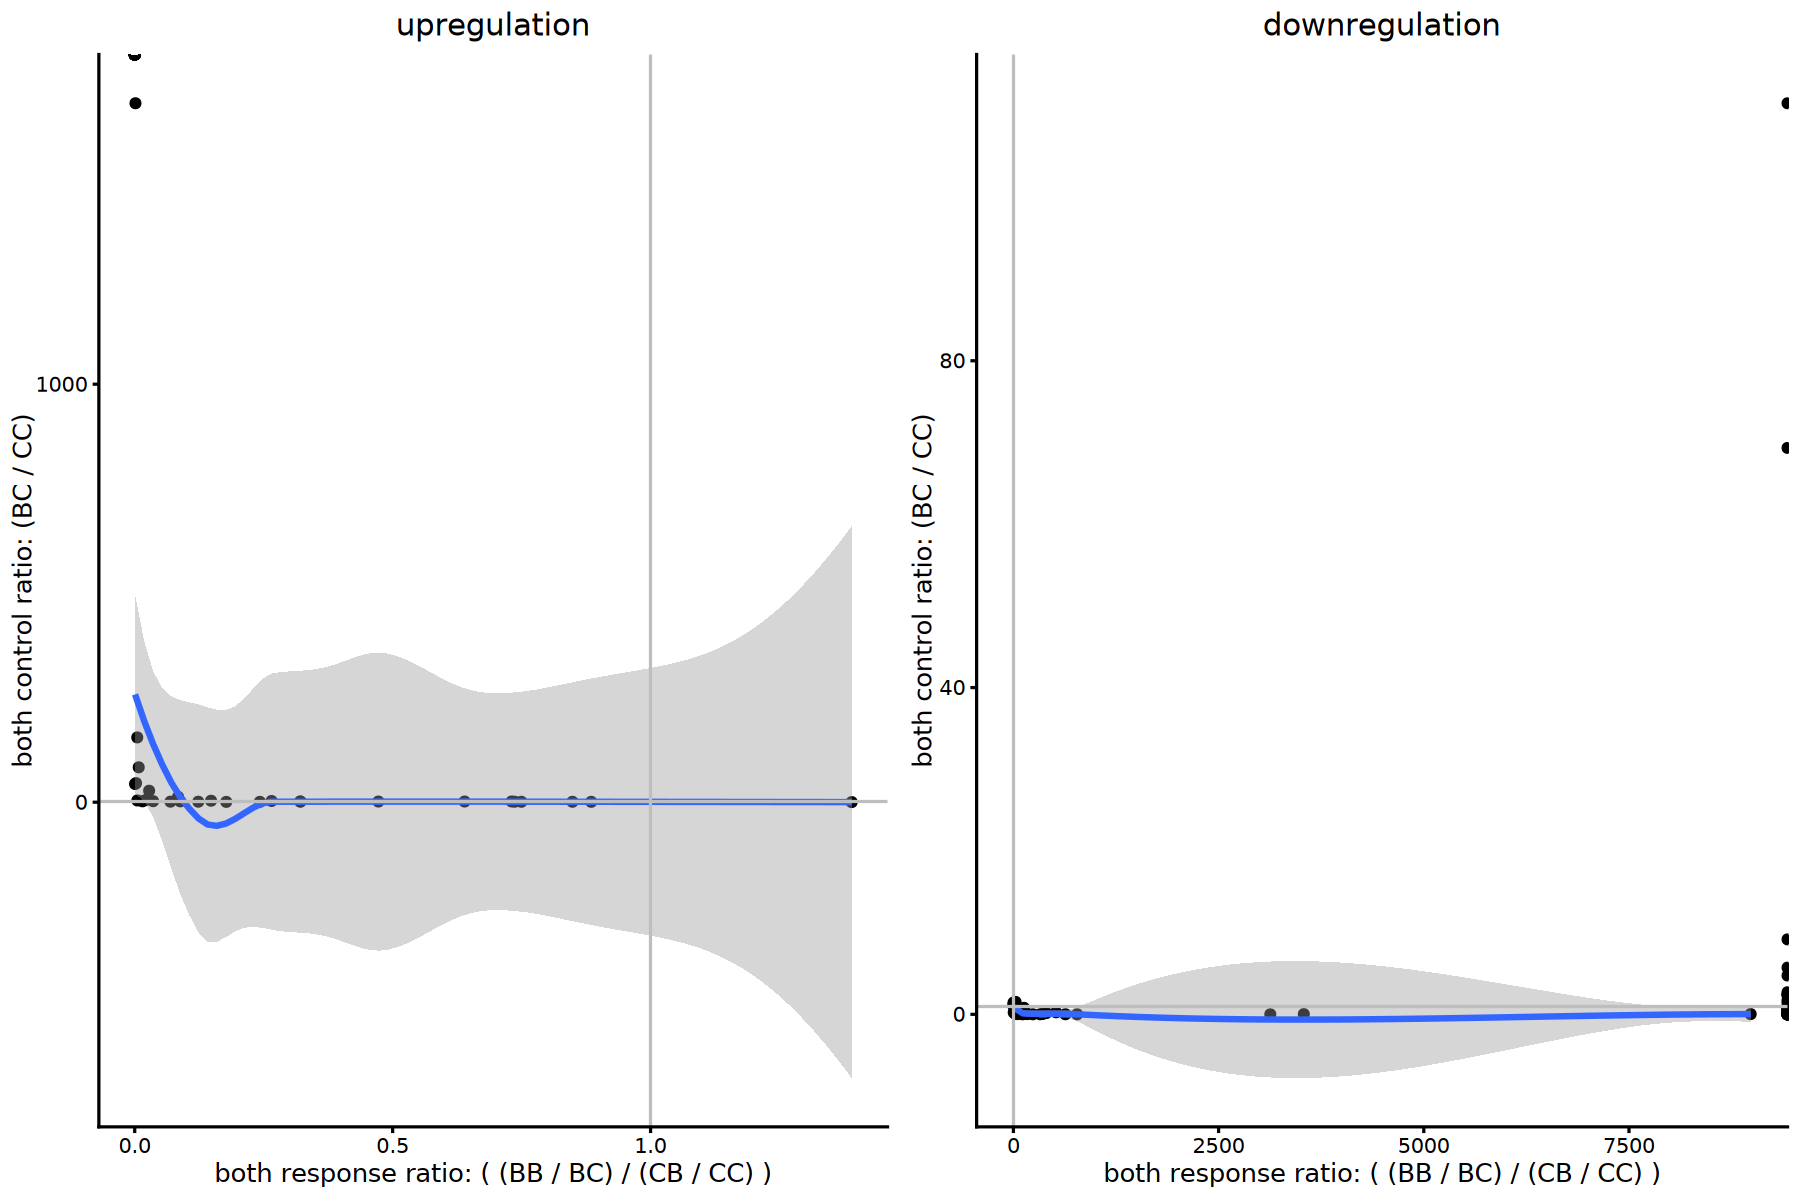

In [40]:
options(repr.plot.width=15, repr.plot.height=10)

plot_grid(both.UP.plot, both.DOWN.plot)

it's interesting that for all of these, there's more of a 'spread' for the downregulated genes - i think in all of these comparisons, there are more DEGs that are down-regulated than up-regulated, so maybe that's it??

I also, again, need to think more about the downregulation calculation

### mean vst expression for frontloaded genes
following Gurr et al 2022

In [50]:
### HYPOXIA 
## UPREGULATED

# filter for up-regulated frontloaded genes
fl.hyp.up <- hyp.vsd_UP %>%
filter(x.axis < 1 & y.axis > 1)
dim(fl.hyp.up) # 42 frontloaded genes

treatments <- c('control_control', 'hypoxic_control', 'control_hypoxic', 'hypoxic_hypoxic')

# pull those out of meta_vsd
fl.hyp.up <- meta_vsd[meta_vsd$Gene %in% fl.hyp.up$Gene,] %>%
filter(All_treatment == treatments)

hyp_mean.sd <- fl.hyp.up %>%
group_by(All_treatment) %>%
summarise(meanExp = mean(Expression),
          seExp = sd(Expression) / sqrt(n()), # standard error 
          ) %>%
separate(col = All_treatment, into = c('phase1', 'phase2'), sep = '_')

hyp_mean.sd

[1] 42 19

phase1,phase2,meanExp,seExp
<chr>,<chr>,<dbl>,<dbl>
control,control,7.676525,0.02647232
control,hypoxic,8.083455,0.09456601
hypoxic,control,7.983738,0.09230493
hypoxic,hypoxic,7.933791,0.07926835


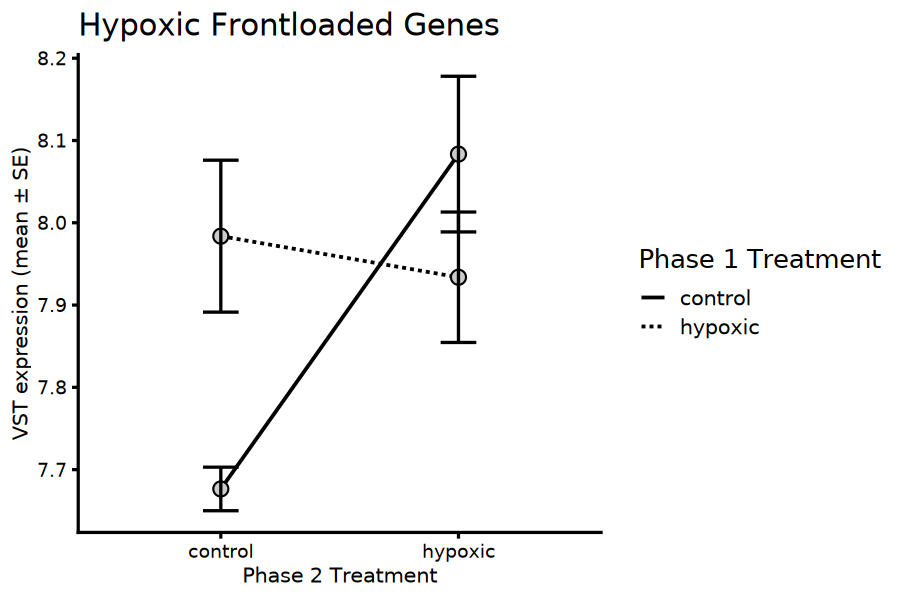

In [77]:
options(repr.plot.width=7.5, repr.plot.height=5)


hyp_vst.plot <- ggplot(hyp_mean.sd, aes(x = phase2, y = meanExp, group = phase1)) +
  # lines
  geom_line(aes(linetype = phase1),
            linewidth = 0.8,
            color = "black") +
  # points
  geom_point(shape = 21,
             size = 3.5,
             fill = "grey80",
             color = "black") +
  # error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
  scale_linetype_manual(
    name = "Phase 1 Treatment",             
    values = c("solid", "dashed")
  ) +
  # labels
  labs(
    x = expression("Phase 2 Treatment"),
    y = "VST expression (mean ± SE)",
      title = 'Hypoxic Frontloaded Genes'
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

hyp_vst.plot

#### observations/conclusions
when the first exposure is control (solid line), the average expression increases when exposed to hypoxia in the phase 2

when the first exposure is hypoxic (dashed lines), the average expression is slightly reduced when the second exposure is hypoxia (reduced reaction)

since the lines cross, this indicates an interaction of phase 1 and 2? 

SE bars do overlap in phase 2 hypoxia - so expression becomes similar in phase 2 hypoxia, regardless of what was experienced in phase 1 

In [58]:
### WARMING 
## UPREGULATED

# filter for up-regulated frontloaded genes
fl.warm.up <- warm.vsd_UP %>%
filter(x.axis < 1 & y.axis > 1)
dim(fl.warm.up) # 42 frontloaded genes

treatments <- c('control_control', 'warm_control', 'control_warm', 'warm_warm')

# pull those out of meta_vsd
fl.warm.up <- meta_vsd[meta_vsd$Gene %in% fl.warm.up$Gene,] %>%
filter(All_treatment == treatments)

warm_mean.sd <- fl.warm.up %>%
group_by(All_treatment) %>%
summarise(meanExp = mean(Expression),
         seExp = sd(Expression) / sqrt(n()), # standard error
         ) %>%
separate(col = All_treatment, into = c('phase1', 'phase2'), sep = '_')

warm_mean.sd

[1] 48 19

phase1,phase2,meanExp,seExp
<chr>,<chr>,<dbl>,<dbl>
control,control,7.746646,0.03492003
control,warm,8.409492,0.13948508
warm,control,8.223749,0.10940821
warm,warm,8.190861,0.10378387


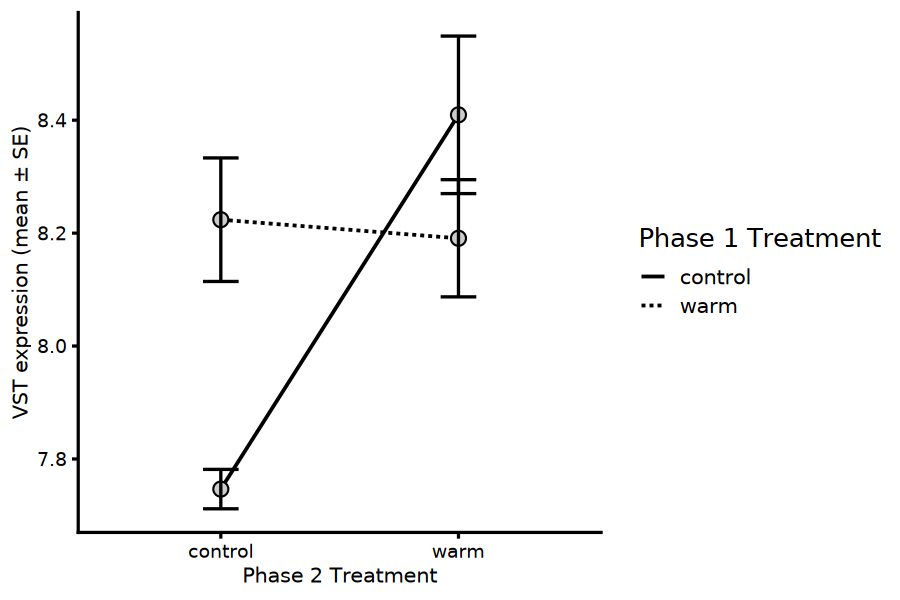

In [107]:
options(repr.plot.width=7.5, repr.plot.height=5)


warm_vst.plot <- ggplot(warm_mean.sd, aes(x = phase2, y = meanExp, group = phase1)) +
  # lines
  geom_line(aes(linetype = phase1),
            linewidth = 0.8,
            color = "black") +
  # points
  geom_point(shape = 21,
             size = 3.5,
             fill = "grey80",
             color = "black") +
  # error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
   scale_linetype_manual(
    name = "Phase 1 Treatment",             
    values = c("solid", "dashed")
  ) +
  # labels
  labs(
    x = expression("Phase 2 Treatment"),
    y = "VST expression (mean ± SE)",
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
warm_vst.plot

#### observations/conclusions
similar conclusions to hypoxia - can see that when oysters are not primed (phase 1 control), there is a large reaction/change in GE, while the primed oysters have a slightly reduced reaction (but not really - largely remain the same)

In [61]:
### BOTH 
## UPREGULATED

# filter for up-regulated frontloaded genes
fl.both.up <- both.vsd_UP %>%
filter(x.axis < 1 & y.axis > 1)
dim(fl.both.up) # 42 frontloaded genes

treatments <- c('control_control', 'both_control', 'control_both', 'both_both')

# pull those out of meta_vsd
fl.both.up <- meta_vsd[meta_vsd$Gene %in% fl.both.up$Gene,] %>%
dplyr::filter(All_treatment == treatments)

both_mean.sd <- fl.both.up %>%
group_by(All_treatment) %>%
summarise(meanExp = mean(Expression),
         seExp = sd(Expression) / sqrt(n()), # standard error
         ) %>%
separate(col = All_treatment, into = c('phase1', 'phase2'), sep = '_')

both_mean.sd

[1] 49 19

Warning message:
“There were 2 warnings in `dplyr::filter()`.
The first warning was:
ℹ In argument: `All_treatment == treatments`.
Caused by warning in `==.default`:
! longer object length is not a multiple of shorter object length
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


phase1,phase2,meanExp,seExp
<chr>,<chr>,<dbl>,<dbl>
both,both,8.303706,0.11913476
both,control,8.366178,0.12040477
control,both,8.480879,0.14453729
control,control,7.871402,0.06530783


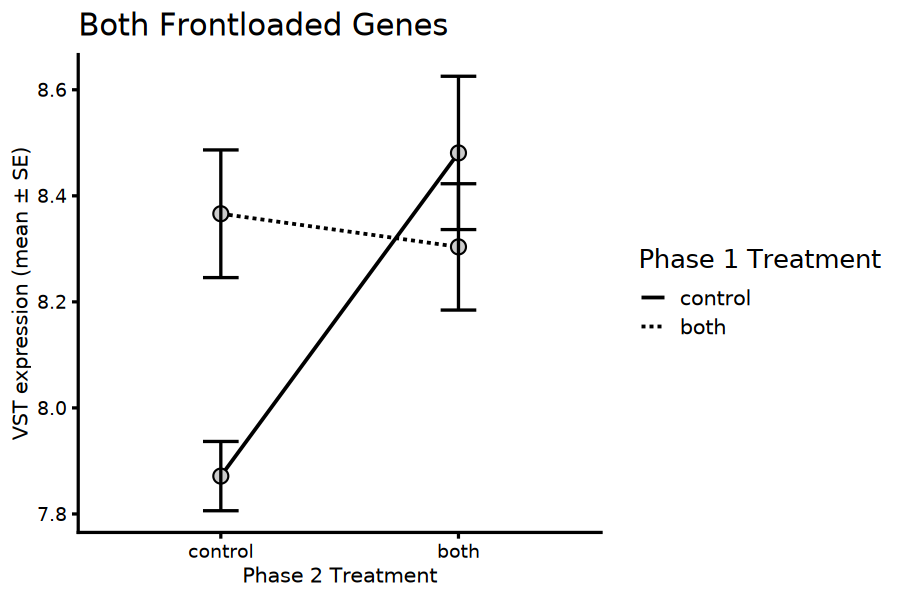

In [80]:
options(repr.plot.width=7.5, repr.plot.height=5)

# add factor for phase 1 to change order on plot
both_mean.sd$phase1 <- factor(both_mean.sd$phase1, c('control', 'both'))
both_mean.sd$phase2 <- factor(both_mean.sd$phase2, c('control', 'both'))


both_vst.plot <- ggplot(both_mean.sd, aes(x = phase2, y = meanExp, group = phase1)) +
  # lines
  geom_line(aes(linetype = phase1),
            linewidth = 0.8,
            color = "black") +
  # points
  geom_point(shape = 21,
             size = 3.5,
             fill = "grey80",
             color = "black") +
  # error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_linetype_manual(
    name = "Phase 1 Treatment",             
    values = c("solid", "dashed")
  ) +  # labels
  labs(
    x = expression("Phase 2 Treatment"),
    y = "VST expression (mean ± SE)",
      title = 'Both Frontloaded Genes'
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
both_vst.plot

#### observations/conclusions
same as hypoxia and warming

### combining frontloading plots with vst expr

In [93]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

`geom_smooth()` using formula = 'y ~ x'


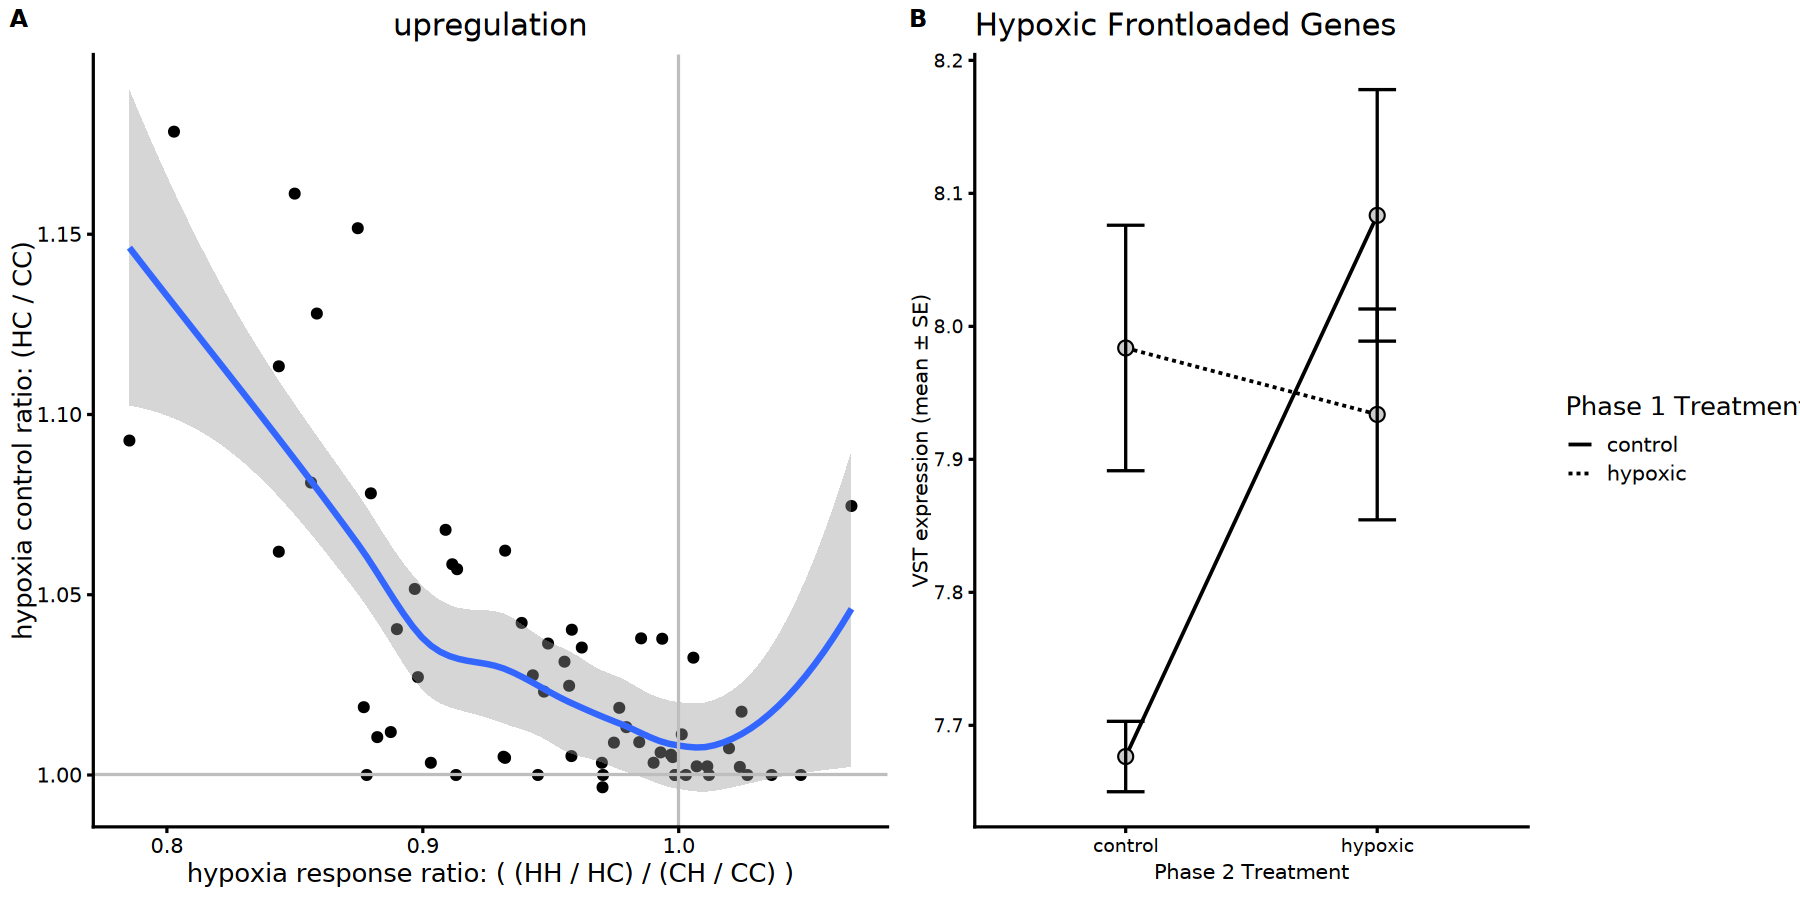

In [97]:
### HYPOXIC
hypoxic <- plot_grid(hyp.UP.plot, hyp_vst.plot, labels = 'AUTO', align = 'h')
hypoxic

In [100]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/hypoxicUp_frontloadedGenes.pdf', hypoxic, width = 15, height = 7.5)

`geom_smooth()` using formula = 'y ~ x'


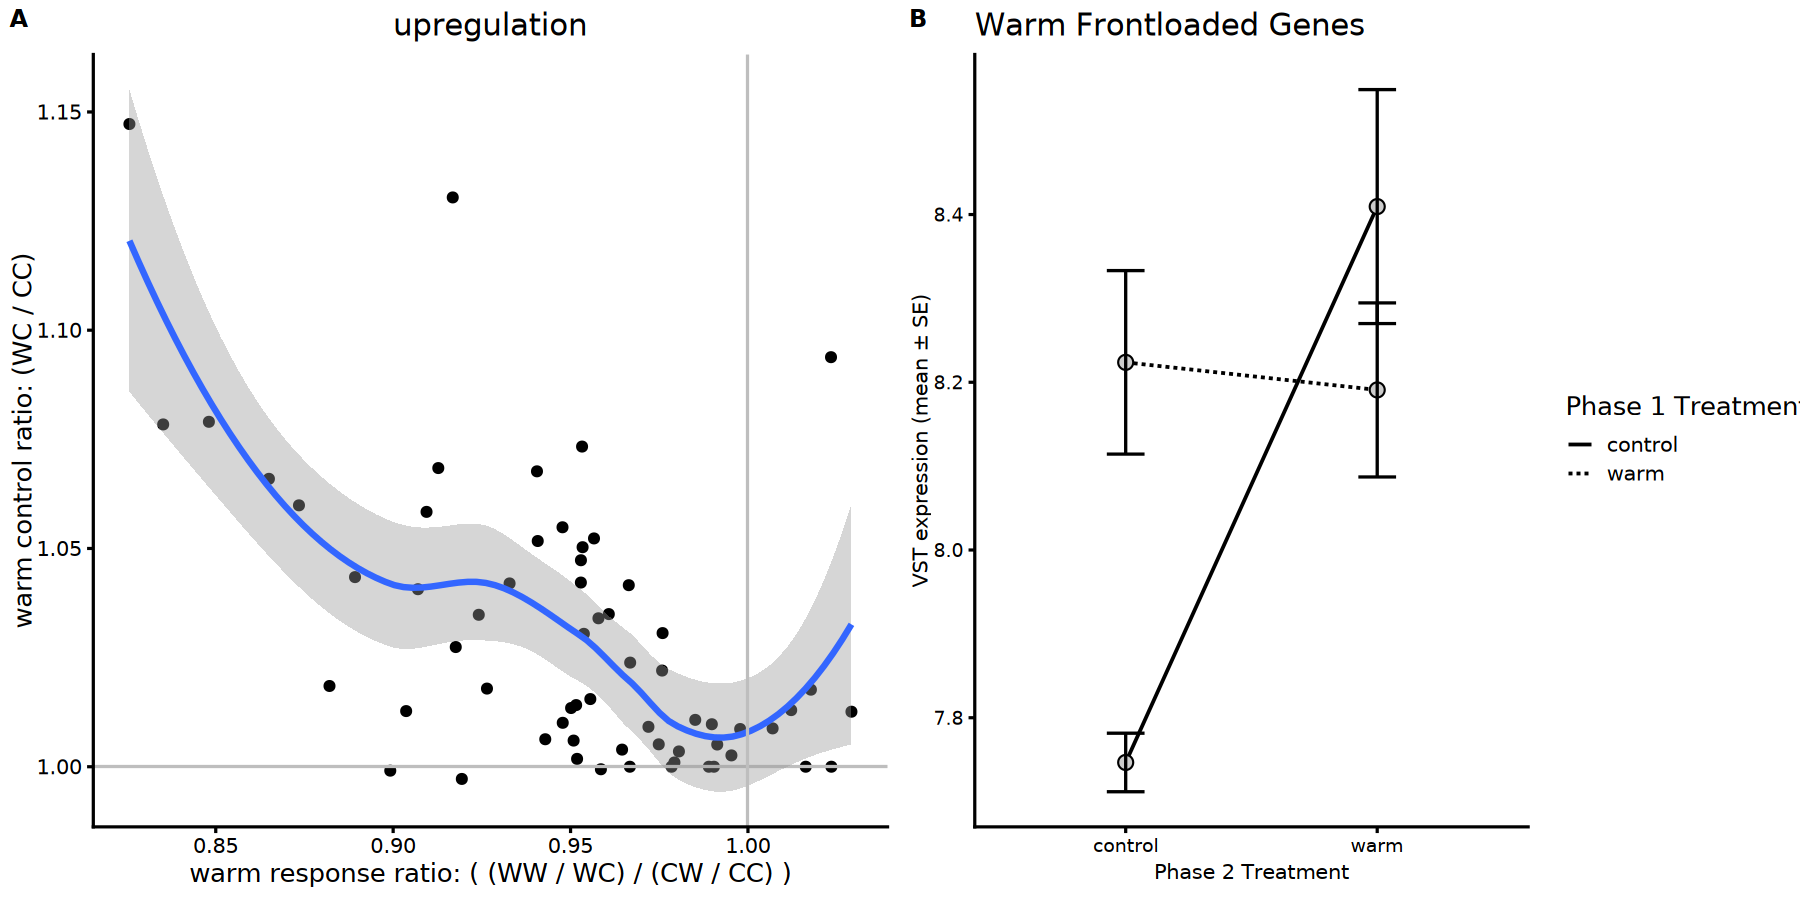

In [99]:
### WARM
warm <- plot_grid(warm.UP.plot, warm_vst.plot, labels = 'AUTO', align = 'h')
warm

In [101]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/warmUp_frontloadedGenes.pdf',warm, width = 15, height = 7.5)

`geom_smooth()` using formula = 'y ~ x'


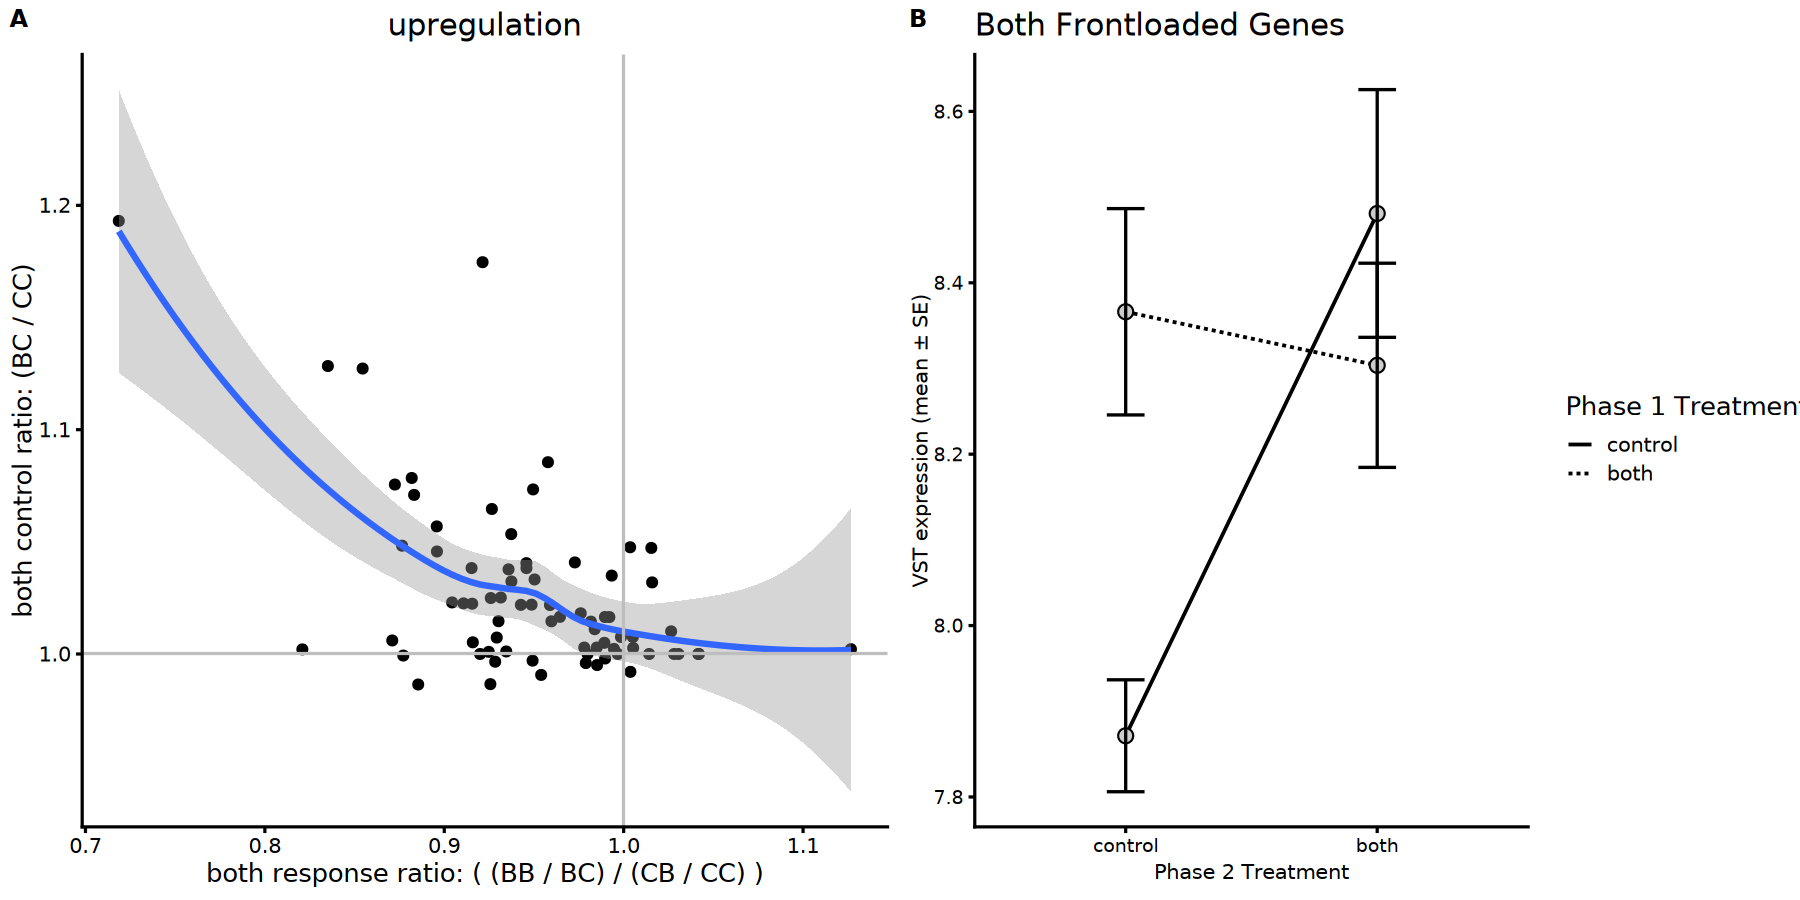

In [102]:
### BOTH
both <- plot_grid(both.UP.plot, both_vst.plot, labels = 'AUTO', align = 'h')
both

In [103]:
ggsave('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/plots/bothUp_frontloadedGenes.pdf',both, width = 15, height = 7.5)

### generating plot for talk

In [105]:
warm_p1C <- warm_mean.sd %>%
filter(phase1 == 'control')

warm_p1C

phase1,phase2,meanExp,seExp
<chr>,<chr>,<dbl>,<dbl>
control,control,7.746646,0.03492003
control,warm,8.409492,0.13948508


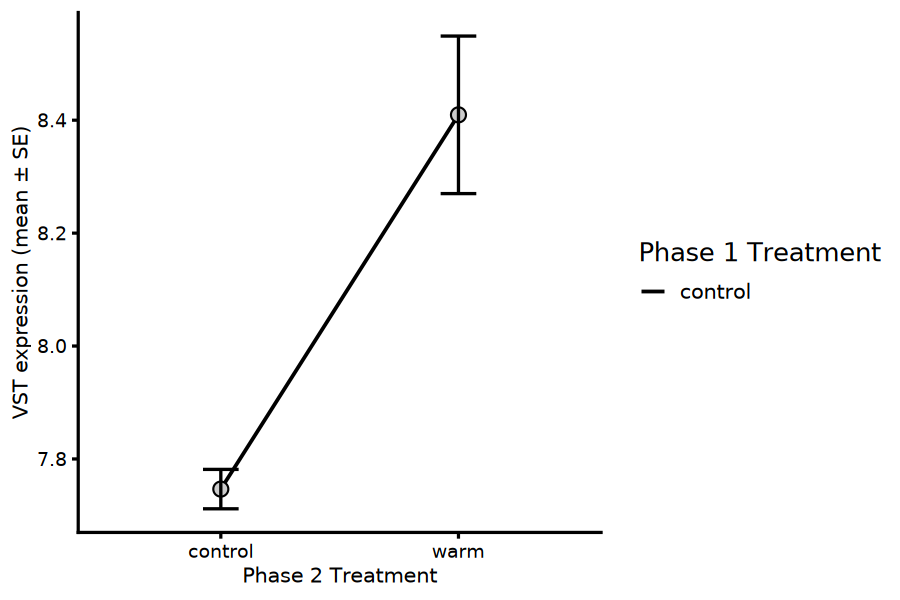

In [106]:
options(repr.plot.width=7.5, repr.plot.height=5)


ggplot(warm_p1C, aes(x = phase2, y = meanExp, group = phase1)) +
  # lines
  geom_line(aes(linetype = phase1),
            linewidth = 0.8,
            color = "black") +
  # points
  geom_point(shape = 21,
             size = 3.5,
             fill = "grey80",
             color = "black") +
  # error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
   scale_linetype_manual(
    name = "Phase 1 Treatment",             
    values = c("solid", "dashed")
  ) +
  # labels
  labs(
    x = expression("Phase 2 Treatment"),
    y = "VST expression (mean ± SE)"
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
